# Temporal Difference Learning on Cliff Gridworld

## Theory

### Temporal Difference Learning

Temporal Difference (TD) learning is a combination of Monte Carlo ideas and Dynamic Programming ideas. Like Monte Carlo methods, TD methods can learn directly from raw experience without a model of the environment's dynamics. Like Dynamic Programming, TD methods update estimates based in part on other learned estimates, without waiting for a final outcome (a process known as *bootstrapping*).

The fundamental TD update for state-action values is:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \right]$$


In [1]:
import matplotlib.pyplot as plt
import numpy as np


## Problem Modeling

### The Cliff Gridworld

The environment is a $4 \times 12$ grid. The agent starts at the bottom-left corner and aims to reach the goal at the bottom-right corner.

- **State Space ($S$):** A set of 48 discrete states representing the grid coordinates $(row, col)$.
- **Action Space ($A$):** Four discrete actions: Up (0), Down (1), Left (2), Right (3).
- **Reward Function ($R$):**
  - $-100$ for stepping into the "Cliff" (the intermediate cells in the bottom row).
  - $-1$ for every other transition.
- **Transition Dynamics ($P$):**
  - Deterministic movement.
  - If the agent hits the Cliff, it is instantly teleported back to the Start state, but the episode continues.
  - If the agent hits a boundary wall, it remains in its current cell.
- **Termination:** The episode ends only when the Goal state is reached.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

class Environment:
    def __init__(self, grid_layout):
        self.grid = np.array(grid_layout)
        self.rows, self.cols = self.grid.shape
        start_indices = np.where(self.grid == 1)
        self.start_pos = (start_indices[0][0], start_indices[1][0])
        self.current_pos = self.start_pos

    def reset(self):
        self.current_pos = self.start_pos
        return self.current_pos

    def step(self, action):
        moves = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        dr, dc = moves[action]
        next_r, next_c = self.current_pos[0] + dr, self.current_pos[1] + dc

        # Wall Logic: Stay in place if out of bounds
        if not (0 <= next_r < self.rows and 0 <= next_c < self.cols):
            next_r, next_c = self.current_pos

        next_pos = (next_r, next_c)
        cell_type = self.grid[next_pos]

        if cell_type == 2:  # Cliff
            reward = -100
            self.current_pos = self.start_pos
            done = False
        elif cell_type == 3:  # Goal
            reward = -1
            self.current_pos = next_pos
            done = True
        else:
            reward = -1
            self.current_pos = next_pos
            done = False

        return self.current_pos, reward, done

## Algorithms

In this project, we compare three primary TD control algorithms:

### 1. SARSA: On-Policy TD Control

SARSA is an on-policy algorithm, meaning it learns the value of the policy currently being followed, including the exploration steps.

**SARSA Update Rule:**
$$Q(S, A) \leftarrow Q(S, A) + \alpha \left[ R + \gamma Q(S', A') - Q(S, A) \right]$$

![alt text](sarsa.png)

### 2. Q-Learning: Off-Policy TD Control

Q-Learning is off-policy; it learns the values of the optimal policy (the greedy policy) independently of the agent's actions, which are generated by an $\epsilon$-greedy policy.

**Q-Learning Update Rule:**
$$Q(S, A) \leftarrow Q(S, A) + \alpha \left[ R + \gamma \max_a Q(S', a) - Q(S, A) \right]$$

![alt text](q-pol.png)

### 3. Expected SARSA

Expected SARSA is a variation that uses the expected value of the next state-action pair, moving deterministically in the same direction as SARSA moves in expectation. It reduces the variance found in SARSA due to random action selection.

**Expected SARSA Update Rule:**
$$Q(S, A) \leftarrow Q(S, A) + \alpha \left[ R + \gamma \sum_{a'} \pi(a'|S') Q(S', a') - Q(S, A) \right]$$

where $\pi(a'|S')$ is the probability of selecting action $a'$ in state $S'$ under the behavior policy (e.g. $\epsilon$-greedy).

**Pseudocode for Expected SARSA:**
1. Initialize $Q(s, a)$ arbitrarily
2. For each episode:
   1. Initialize state $S$
   2. For each step of the episode:
      1. Choose action $A$ from $S$ using policy derived from $Q$ (e.g., $\epsilon$-greedy)
      2. Take action $A$, observe reward $R$ and next state $S'$
      3. $Q(S, A) \leftarrow Q(S, A) + \alpha \left[ R + \gamma \sum_{a'} \pi(a'|S') Q(S', a') - Q(S, A) \right]$
      4. $S \leftarrow S'$
   3. Until $S$ is terminal


In [3]:
import numpy as np

class Agent:
    def __init__(self, rows, cols, epsilon=0.1, alpha=0.1, gamma=1.0):
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.q_table = np.zeros((rows, cols, 4))

    def choose_action(self, state):
        # Epsilon-greedy policy
        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.randint(0, 4)
        else:
            current_q = self.q_table[state]
            max_q = np.max(current_q)
            # Random tie-breaking for equal Q-values
            actions_with_max_q = np.where(current_q == max_q)[0]
            return np.random.choice(actions_with_max_q)

    # 1. SARSA (On-Policy)
    def update_sarsa(self, state, action, reward, next_state, next_action, done):
        current_q = self.q_table[state][action]
        # If terminal, next_q must be 0
        next_q = 0 if done else self.q_table[next_state][next_action]

        td_target = reward + self.gamma * next_q
        self.q_table[state][action] += self.alpha * (td_target - current_q)

    # 2. Q-Learning (Off-Policy)
    def update_q_learning(self, state, action, reward, next_state, done):
        current_q = self.q_table[state][action]
        # If terminal, max_next_q must be 0
        max_next_q = 0 if done else np.max(self.q_table[next_state])

        td_target = reward + self.gamma * max_next_q
        self.q_table[state][action] += self.alpha * (td_target - current_q)

    # 3. Expected SARSA
    def update_expected_sarsa(self, state, action, reward, next_state, done):
        current_q = self.q_table[state][action]

        if done:
            expected_value = 0
        else:
            q_next = self.q_table[next_state]
            max_q = np.max(q_next)
            num_actions = 4

            # Probability logic for Epsilon-Greedy
            best_actions = (q_next == max_q)
            num_best = np.sum(best_actions)

            # Probability of any specific non-greedy action
            non_greedy_prob = self.epsilon / num_actions
            # Probability of any specific greedy action
            greedy_prob = ((1.0 - self.epsilon) / num_best) + non_greedy_prob

            # Calculate Expected Value: Sum(prob(a) * Q(s,a))
            expected_value = 0
            for a in range(num_actions):
                if q_next[a] == max_q:
                    expected_value += greedy_prob * q_next[a]
                else:
                    expected_value += non_greedy_prob * q_next[a]

        td_target = reward + self.gamma * expected_value
        self.q_table[state][action] += self.alpha * (td_target - current_q)

## Implementation

The implementation is written in Python using a modular approach. It consists of:
- **Environment class:** Handles the grid logic, state transitions, wall physics, and reward logic.
- **Agent class:** Maintains the $Q$-table and performs updates for the three TD algorithms (SARSA, Q-learning, and Expected SARSA).

### Key Implementation Details
- **$\epsilon$-greedy Policy:** Used by all agents to ensure exploration.
- **Q-Table:** A 3D NumPy array of shape $(4, 12, 4)$ initialized to zeros.
- **Experimentation:** Performance is measured by the *sum of rewards per episode* to capture the cost of exploration and cliff falls.


In [4]:
def get_interim_performance(method, alpha, episodes=100, runs=50, grid_map=None):
    performance_per_run = []

    for _ in range(runs):
        if grid_map is None:
            current_grid = np.zeros((4, 12), dtype=int)
            current_grid[3, 0] = 1
            current_grid[3, 1:11] = 2
            current_grid[3, 11] = 3
        else:
            current_grid = np.array(grid_map, copy=True)

        env = Environment(current_grid)
        agent = Agent(env.rows, env.cols, epsilon=0.1, alpha=alpha)

        run_rewards = []
        for _ in range(episodes):
            state = env.reset()
            action = agent.choose_action(state)
            episode_reward = 0
            while True:
                next_state, reward, done = env.step(action)
                episode_reward += reward
                next_action = agent.choose_action(next_state)

                if method == 'Sarsa':
                    agent.update_sarsa(state, action, reward, next_state, next_action, done)
                elif method == 'Q-Learning':
                    agent.update_q_learning(state, action, reward, next_state, done)
                elif method == 'Expected Sarsa':
                    agent.update_expected_sarsa(state, action, reward, next_state, done)

                state, action = next_state, next_action
                if done: break
            run_rewards.append(episode_reward)

        performance_per_run.append(np.mean(run_rewards))

    return np.mean(performance_per_run)

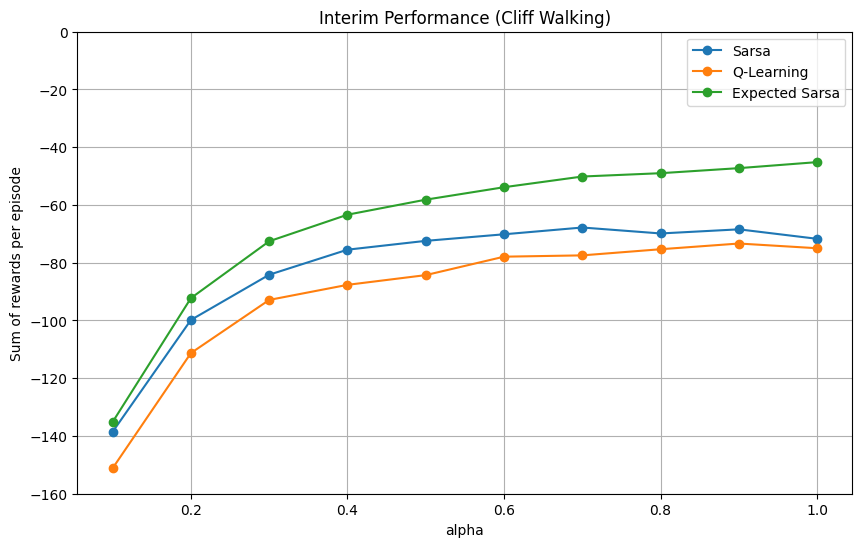

In [5]:
alphas = np.arange(0.1, 1.1, 0.1)
methods = ['Sarsa', 'Q-Learning', 'Expected Sarsa']
results = {m: [] for m in methods}

for m in methods:
    for a in alphas:
        avg_perf = get_interim_performance(m, a)
        results[m].append(avg_perf)

# Plotting
plt.figure(figsize=(10, 6))
for m in methods:
    plt.plot(alphas, results[m], label=m, marker='o')

plt.xlabel('alpha')
plt.ylabel('Sum of rewards per episode')
plt.title('Interim Performance (Cliff Walking)')
plt.ylim(-160, 0) # Adjust based on your results
plt.legend()
plt.grid(True)
plt.show()

## Analysis and Observations

### Sarsa vs. Q-Learning Path Visualization

- **Q-Learning** tends to learn the *optimal* path, walking directly along the cliff edge.
- **Sarsa** learns the *safe* path, keeping away from the cliff.

**Insight:** Sarsa is *conservative* because it accounts for the $-100$ penalty it might incur due to its own $\epsilon$-greedy exploration. Q-Learning is *optimistic*, assuming it will always act greedily in the future, even if it currently explores.

### Hyperparameter Sensitivity: The $\alpha$ Effect

- **Choice of parameters:** We selected specific values for $\alpha$ (step-size) and $\epsilon$ (exploration) to balance learning speed and stability.
- **Experimental observation:** Setting $\alpha$ too high (e.g., 0.9) caused interim performance to oscillate wildly. The agent overreacted to the $-100$ cliff rewards, temporarily "forgetting" the path to the goal.
- **Expected Sarsa stability:** Expected Sarsa averages over all possible actions rather than sampling a single next action. This averaging reduces variance, making it much more stable at high $\alpha$ values compared to Sarsa.

### Comparison of TD Update Targets

The table below summarizes the target calculations of each TD algorithm:

| **Algorithm** | **Target Calculation** | **Logic** |
| :--- | :--- | :--- |
| **Sarsa** | $R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$ | Uses the actual next action taken |
| **Q-Learning** | $R_{t+1} + \gamma \max_a Q(S_{t+1}, a)$ | Uses the best possible next action |
| **Expected Sarsa** | $R_{t+1} + \gamma \sum_a \pi(a\|S_{t+1}) Q(S_{t+1}, a)$ | Averages over all actions according to policy $\pi$ |
